# Tuần 1 — Wine Dataset
Thành Viên 1: Chuyên gia Dữ liệu & Trực quan hóa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Bước 1: Đọc file và đặt tên cột

In [4]:
df = pd.read_excel('Wine-Classification-DataMining/wine.data.xlsx', sheet_name='wine.data', header=0)
col_names = [
    'Class','Alcohol','Malic_Acid','Ash','Alcalinity_of_Ash',
    'Magnesium','Total_Phenols','Flavanoids','Nonflavanoid_Phenols',
    'Proanthocyanins','Color_Intensity','Hue','OD280_OD315','Proline'
]
df.columns = col_names
df['Class'] = df['Class'].astype(int)
df.head()

,Class,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280_OD315,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Bước 2: Kiểm tra tổng quan dataset

In [5]:
print(f'Kich thuoc: {df.shape[0]} mau x {df.shape[1]} cot')
print('\nKieu du lieu:')
print(df.dtypes)
print('\nSo mau theo nhan:')
print(df['Class'].value_counts().sort_index())

Kich thuoc: 178 mau x 14 cot

Kieu du lieu:
Class                     int64
Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Alcalinity_of_Ash       float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280_OD315             float64
Proline                   int64
dtype: object

So mau theo nhan:
Class
1    59
2    71
3    48
Name: count, dtype: int64


## Bước 3: Thống kê Max / Min / Mean

In [6]:
features = col_names[1:]
stats = df[features].agg(['max', 'min', 'mean']).T.round(4)
stats.columns = ['Max', 'Min', 'Mean']
print(stats)

                          Max     Min      Mean
Alcohol                 14.83   11.03   13.0006
Malic_Acid               5.80    0.74    2.3363
Ash                      3.23    1.36    2.3665
Alcalinity_of_Ash       30.00   10.60   19.4949
Magnesium              162.00   70.00   99.7416
Total_Phenols            3.88    0.98    2.2951
Flavanoids               5.08    0.34    2.0293
Nonflavanoid_Phenols     0.66    0.13    0.3619
Proanthocyanins          3.58    0.41    1.5909
Color_Intensity         13.00    1.28    5.0581
Hue                      1.71    0.48    0.9574
OD280_OD315              4.00    1.27    2.6117
Proline               1680.00  278.00  746.8933


## Bước 4: Chuẩn hóa dữ liệu với StandardScaler

In [7]:
scaler = StandardScaler()
X = df[features].values
X_scaled = scaler.fit_transform(X)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled.insert(0, 'Class', df['Class'].values)
df_scaled.to_csv('wine_scaled.csv', index=False)
print('Da luu: scaler.pkl')
print('Da luu: wine_scaled.csv')

Da luu: scaler.pkl
Da luu: wine_scaled.csv


## Bước 5: PCA 2D và Scatter Plot

PC1: 36.2%  PC2: 19.2%  Tong: 55.4%


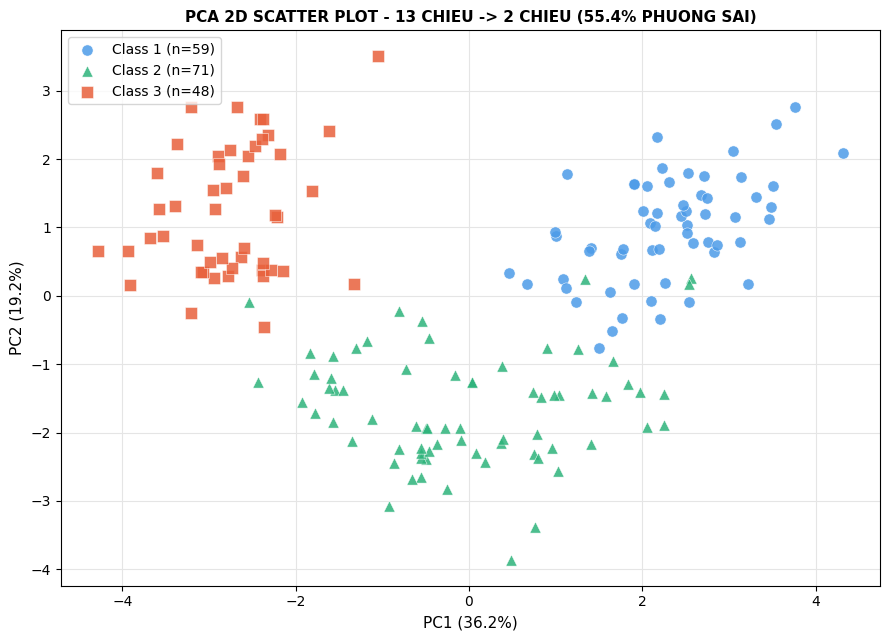

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_
print(f'PC1: {ev[0]*100:.1f}%  PC2: {ev[1]*100:.1f}%  Tong: {sum(ev)*100:.1f}%')
colors  = {1: '#4C9BE8', 2: '#2DB37A', 3: '#E8613C'}
markers = {1: 'o', 2: '^', 3: 's'}
labels  = df['Class'].values
counts  = df['Class'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
for cls in [1, 2, 3]:
    mask = labels == cls
    ax.scatter(X_pca[mask,0], X_pca[mask,1], c=colors[cls], marker=markers[cls],
               label=f'Class {cls} (n={counts[cls]})', alpha=0.85,
               edgecolors='white', linewidths=0.4, s=65, zorder=3)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontsize=11)
ax.set_title(f'PCA 2D SCATTER PLOT - 13 CHIEU -> 2 CHIEU ({sum(ev)*100:.1f}% PHUONG SAI)', fontsize=11, fontweight='bold')
ax.grid(True, color='#e5e5e5', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=True, fontsize=10, loc='upper left')
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Tuần 2 — Wine Dataset

## Bước 1: Khung 10-Fold
* **Mục tiêu:** Tạo bộ chia dữ liệu 10-Fold Cross-Validation đồng nhất cho tất cả các mô hình.
* **Kỹ thuật:** Sử dụng `StratifiedKFold` với `random_state=42` để duy trì tỷ lệ lớp gốc và đảm bảo kết quả tái lập được giữa các thành viên.
* **Độ đo:** `Weighted F1-Score` xử lý dữ liệu mất cân bằng.

In [9]:
# KHUNG KIỂM ĐỊNH CHÉO DÙNG CHUNG CỦA TUẦN 2

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

print("--- ĐANG KHỞI TẠO BỘ KHUNG ĐÁNH GIÁ CHUNG ---")

# Thống nhất khung kiểm định 10-Fold để tất cả các mô hình dùng chung
cv_folds = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Thống nhất độ đo Weighted F1-Score
weighted_f1_scorer = make_scorer(f1_score, average='weighted')

print("-> Đã khởi tạo thành công 'cv_folds' (10-Fold) và 'weighted_f1_scorer'.")

--- ĐANG KHỞI TẠO BỘ KHUNG ĐÁNH GIÁ CHUNG ---
-> Đã khởi tạo thành công 'cv_folds' (10-Fold) và 'weighted_f1_scorer'.


## Bước 2: Huấn luyện và tinh chỉnh tham số cho mô hình KNN (K-Nearest Neighbors)

* **Mục tiêu:** Tìm ra bộ tham số tối ưu giúp mô hình KNN đạt hiệu năng phân loại rượu cao nhất, ổn định nhất và triệt tiêu hiện tượng quá khớp (overfitting).
  + *Tìm số láng giềng $K$ tối ưu:* Thực hiện vòng lặp quét tham số $K$ giới hạn từ 1 đến 30. Khoảng quét này được tính toán khoa học dựa trên quy tắc kinh nghiệm $K \approx \sqrt{N}$ (với dữ liệu Wine có $N=178$ mẫu thì $\sqrt{178} \approx 13$). Giới hạn tối đa bằng 30 nhằm đảm bảo số láng giềng không vượt quá số lượng mẫu của lớp nhỏ nhất trong tập dữ liệu (Class 3 có 48 mẫu), tránh hiện tượng mô hình bị bão hòa và dự đoán cảm tính (Underfitting).
  + *Xác định loại khoảng cách phù hợp:* Thử nghiệm và so sánh giữa khoảng cách hình học thẳng (**Euclidean** - Minkowski $p=2$) và khoảng cách theo khối ô bàn cờ (**Manhattan** - Minkowski $p=1$) xem công thức nào phản ánh chính xác hơn mức độ tương đồng giữa các thuộc tính hóa học của rượu.
  + *Cân bằng quyền bỏ phiếu (Weights):* Đánh giá hai cơ chế bỏ phiếu là `uniform` (tất cả hàng xóm có giá trị phiếu bầu như nhau) và `distance` (hàng xóm càng gần thì trọng số phiếu bầu càng cao) để tối ưu hóa ranh giới phân lớp.
  + *Quét cạn tự động (GridSearchCV):* Thuật toán sẽ tự động thiết lập và thử nghiệm tổng cộng 120 cấu hình kết hợp khác nhau ($30 \times 2 \times 2$).

* **Kế thừa:** + Sử dụng lại tập dữ liệu đã được xử lý và chuẩn hóa (`X_scaled`, `labels`) từ **Thành viên 1 (Tuần 1)**.
  + Tái sử dụng bộ khung kiểm định chéo Phân tầng 10 vế (`cv_folds`) và tiêu chí chấm điểm `weighted_f1_scorer` đã thiết lập ở **Bước 1 (Tuần 2)** để đảm bảo tính công bằng tuyệt đối khi so sánh hiệu năng trực tiếp với mô hình Naive Bayes.

--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ KNN ---

[Đang chạy] Quét 120 cấu hình kết hợp trên khung 10-Fold CV...
-------------------------------------------------------
KẾT QUẢ TỐI ƯU MÔ HÌNH KNN:
-> Số lượng láng giềng (K) tốt nhất: 23
-> Loại khoảng cách tối ưu: Euclidean (p=2)
-> Cơ chế bỏ phiếu (Weights): distance
-> Weighted F1-Score cao nhất đạt được: 0.9834
-------------------------------------------------------


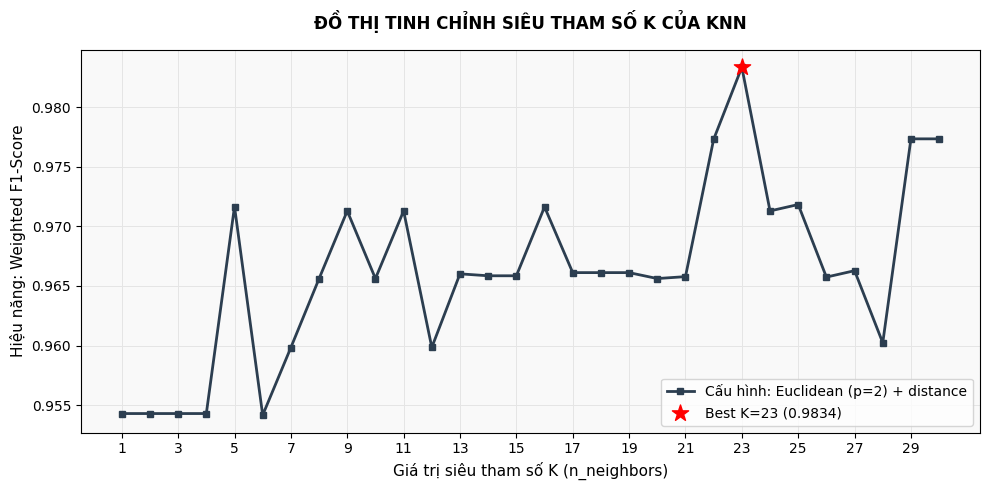

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt

print("--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ KNN ---\n")

# 1. Kế thừa dữ liệu từ Thành viên 1
X_input = X_scaled
y_input = labels

# 2. Khởi tạo mô hình KNN gốc
knn_model = KNeighborsClassifier()

# 3. Thiết lập lưới tham số thực nghiệm chi tiết
param_grid_knn = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # p=1 là Manhattan, p=2 là Euclidean
}

print(f"[Đang chạy] Quét {30 * 2 * 2} cấu hình kết hợp trên khung 10-Fold CV...")

# 4. Kích hoạt GridSearchCV (Kế thừa 'cv_folds' và 'weighted_f1_scorer')
grid_search_knn = GridSearchCV(
    estimator=knn_model,
    param_grid=param_grid_knn,
    cv=cv_folds,
    scoring=weighted_f1_scorer,
    n_jobs=-1
)
grid_search_knn.fit(X_input, y_input)

# 5. Trích xuất kết quả tối ưu
best_knn_params = grid_search_knn.best_params_
best_knn_f1 = grid_search_knn.best_score_
best_knn_model = grid_search_knn.best_estimator_

distance_metric = "Manhattan (p=1)" if best_knn_params['p'] == 1 else "Euclidean (p=2)"

print("-" * 55)
print("KẾT QUẢ TỐI ƯU MÔ HÌNH KNN:")
print(f"-> Số lượng láng giềng (K) tốt nhất: {best_knn_params['n_neighbors']}")
print(f"-> Loại khoảng cách tối ưu: {distance_metric}")
print(f"-> Cơ chế bỏ phiếu (Weights): {best_knn_params['weights']}")
print(f"-> Weighted F1-Score cao nhất đạt được: {best_knn_f1:.4f}")
print("-" * 55)

# 6. Trực quan hóa tiến trình tìm K
cv_results = grid_search_knn.cv_results_
best_p = best_knn_params['p']
best_weight = best_knn_params['weights']

k_values = []
scores_for_best_config = []

for i in range(len(cv_results['params'])):
    params = cv_results['params'][i]
    if params['p'] == best_p and params['weights'] == best_weight:
        k_values.append(params['n_neighbors'])
        scores_for_best_config.append(cv_results['mean_test_score'][i])

sort_idx = np.argsort(k_values)
k_values = np.array(k_values)[sort_idx]
scores_for_best_config = np.array(scores_for_best_config)[sort_idx]

plt.figure(figsize=(10, 5), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#f9f9f9')

plt.plot(k_values, scores_for_best_config, color='#2c3e50', marker='s', markersize=4,
         linestyle='-', linewidth=2, label=f'Cấu hình: {distance_metric} + {best_weight}')

plt.scatter(best_knn_params['n_neighbors'], best_knn_f1, color='red', marker='*',
            s=150, zorder=5, label=f"Best K={best_knn_params['n_neighbors']} ({best_knn_f1:.4f})")

plt.xticks(range(1, 31, 2))
plt.xlabel('Giá trị siêu tham số K (n_neighbors)', fontsize=11)
plt.ylabel('Hiệu năng: Weighted F1-Score', fontsize=11)
plt.title('ĐỒ THỊ TINH CHỈNH SIÊU THAM SỐ K CỦA KNN', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, color='#e5e5e5', linewidth=0.7)
plt.legend(frameon=True, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('knn_tuning.png', dpi=150)
plt.show()

In [19]:
import pandas as pd

# Chuyển kết quả quét của GridSearchCV thành bảng DataFrame
df_results = pd.DataFrame(grid_search_knn.cv_results_)

# Lọc ra các cột quan trọng và đổi tên cho dễ đọc
df_top5 = df_results[['param_n_neighbors', 'param_p', 'param_weights', 'mean_test_score', 'std_test_score']]
df_top5 = df_top5.rename(columns={
    'param_n_neighbors': 'Số láng giềng (K)',
    'param_p': 'Tham số p',
    'param_weights': 'Cơ chế Weights',
    'mean_test_score': 'Weighted F1-Score (TB)',
    'std_test_score': 'Độ lệch chuẩn (Std)'
})

# Sắp xếp theo điểm số từ cao xuống thấp và lấy Top 5
df_top5 = df_top5.sort_values(by='Weighted F1-Score (TB)', ascending=False).head(5)

print("TOP 5 CẤU HÌNH KNN XUẤT SẮC NHẤT:")
display(df_top5)

TOP 5 CẤU HÌNH KNN XUẤT SẮC NHẤT:


,Số láng giềng (K),Tham số p,Cơ chế Weights,Weighted F1-Score (TB),Độ lệch chuẩn (Std)
91,23,2,distance,0.983372,0.025400
45,12,1,distance,0.982874,0.036799
41,11,1,distance,0.982874,0.036799
40,11,1,uniform,0.982874,0.036799
5,2,1,distance,0.977817,0.027169


### Nhận xét kết quả mô hình KNN:
- Quá trình tinh chỉnh siêu tham số bằng `GridSearchCV` trên 120 cấu hình khác nhau đã xác định được bộ tham số tối ưu cho mô hình KNN trên tập dữ liệu Wine bao gồm: số láng giềng **$K=23$**, khoảng cách hình học đường thẳng **`Euclidean (p=2)`** và cơ chế bỏ phiếu ưu tiên theo khoảng cách **`distance`**.
- Mô hình đạt hiệu năng phân loại vượt trội với điểm số `Weighted F1-Score` đạt **0.9834** (98.34%).
- **Phân tích đồ thị:** Biểu đồ Validation Curve cho thấy rõ xu hướng của thuật toán KNN trên tập dữ liệu này. Khi $K$ nhỏ ($K \le 4$), mô hình có hiệu năng thấp do nhạy cảm với nhiễu (Overfitting). Hiệu năng cải thiện rõ rệt và đạt đỉnh tại $K=23$ nhờ vào cơ chế trọng số `distance` giúp cân bằng quyền bỏ phiếu của các láng giềng xa-gần, mang lại ranh giới phân lớp chính xác và mượt mà nhất.

--- ĐANG TRỰC QUAN HÓA RANH GIỚI QUYẾT ĐỊNH KNN (2D) ---


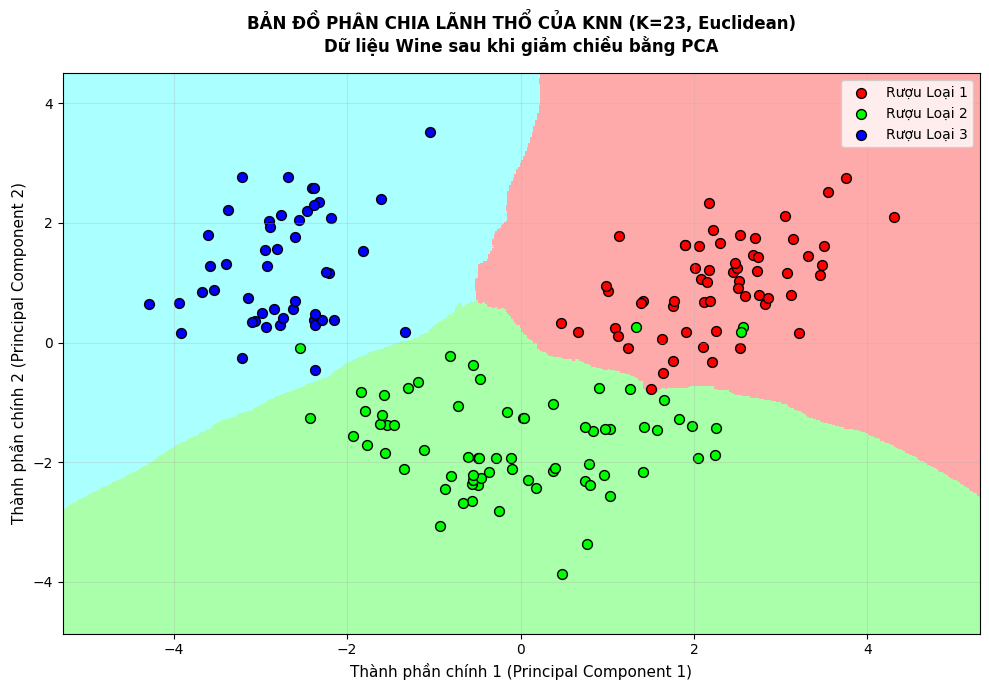

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

print("--- ĐANG TRỰC QUAN HÓA RANH GIỚI QUYẾT ĐỊNH KNN (2D) ---")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled) # Kế thừa X_scaled từ Tuần 1

# 2. Huấn luyện lại mô hình KNN tối ưu (K=23, Euclidean, Distance) trên không gian 2D này
knn_2d = KNeighborsClassifier(n_neighbors=23, p=2, weights='distance')
knn_2d.fit(X_pca, labels) # Kế thừa nhãn labels từ Tuần 1

# 3. Tạo một lưới tọa độ (Meshgrid) dày đặc để tô màu nền cho từng vùng lãnh thổ
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Dự đoán nhãn cho từng điểm trên lưới tọa độ dày đặc đó
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Thiết lập màu sắc (Bảng màu nhẹ cho nền và màu đậm cho điểm dữ liệu thực tế)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAFFFF']) # Màu nền đại diện 3 Class rượu
cmap_bold = ['#FF0000', '#00FF00', '#0000FF'] # Màu điểm thực tế

# 5. Tiến hành vẽ đồ thị
plt.figure(figsize=(10, 7), facecolor='white')
# Tô màu nền lãnh thổ phân chia của KNN
plt.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')

# Vẽ các điểm dữ liệu thực tế của tập Wine lên bản đồ
for cl in np.unique(labels):
    plt.scatter(X_pca[labels == cl, 0], X_pca[labels == cl, 1],
                c=cmap_bold[cl-1], edgecolor='k', s=50,
                label=f'Rượu Loại {cl}')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xlabel('Thành phần chính 1 (Principal Component 1)', fontsize=11)
plt.ylabel('Thành phần chính 2 (Principal Component 2)', fontsize=11)
plt.title('BẢN ĐỒ PHÂN CHIA LÃNH THỔ CỦA KNN (K=23, Euclidean)\nDữ liệu Wine sau khi giảm chiều bằng PCA',
          fontsize=12, fontweight='bold', pad=15)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('knn_decision_boundary.png', dpi=150)
plt.show()

*Lưu ý kỹ thuật:* - Đồ thị tinh chỉnh siêu tham số (Validation Curve) thể hiện kết quả tìm kiếm K trên không gian dữ liệu gốc 13 chiều (Đạt đỉnh tối ưu tại K=23, F1-Score = 0.9834).
- Đồ thị Ranh giới quyết định (Decision Boundary) sử dụng thuật toán PCA để nén dữ liệu về 2 chiều nhằm mục đích trực quan hóa cấu trúc phân lớp cho người xem, do đó ranh giới hiển thị mang tính chất minh họa cho cơ chế hoạt động của KNN và không đại diện hoàn toàn cho độ chính xác trong không gian 13 chiều thực tế.

## Bước 3: Huấn luyện và tinh chỉnh tham số cho mô hình Naive Bayes
* **Mục tiêu:** Tinh chỉnh hệ số làm mịn `var_smoothing` bằng `GridSearchCV`.
* **Kế thừa:** Sử dụng lại dữ liệu chuẩn hóa từ Tuần 1 và khung đánh giá từ Bước 1.

--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ NAIVE BAYES ---

[Đang chạy] Quét 100 giá trị tham số trên 10-Fold CV...
-------------------------------------------------------
KẾT QUẢ TỐI ƯU MÔ HÌNH NAIVE BAYES:
-> Tham số var_smoothing tốt nhất: 1.87e-01
-> Weighted F1-Score cao nhất đạt được: 0.9834
-------------------------------------------------------


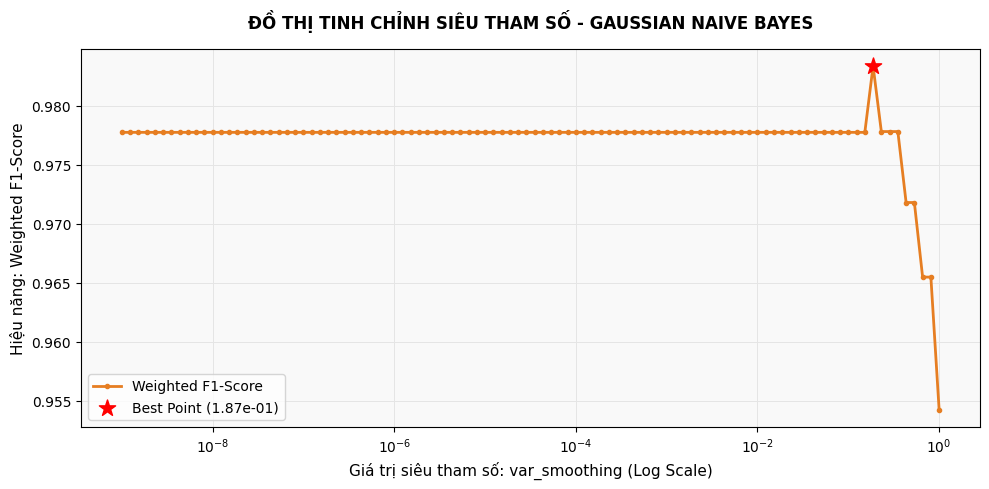

In [10]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
import numpy as np
import matplotlib.pyplot as plt

print("--- TIẾN TRÌNH TỐI ƯU SIÊU THAM SỐ NAIVE BAYES ---\n")

# 1. Kế thừa dữ liệu từ Thành viên 1
X_input = X_scaled
y_input = labels

# 2. Khởi tạo mô hình và không gian lưới 100 bước
nb_model = GaussianNB()
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

# 3. Kích hoạt GridSearchCV (Tự động kế thừa biến 'cv_folds' và 'weighted_f1_scorer' ở ô trên)
print("[Đang chạy] Quét 100 giá trị tham số trên 10-Fold CV...")
grid_search_nb = GridSearchCV(
    estimator=nb_model,
    param_grid=param_grid_nb,
    cv=cv_folds,
    scoring=weighted_f1_scorer,
    n_jobs=-1
)
grid_search_nb.fit(X_input, y_input)

# 4. Trích xuất kết quả tối ưu
best_nb_params = grid_search_nb.best_params_
best_nb_f1 = grid_search_nb.best_score_

print("-" * 55)
print("KẾT QUẢ TỐI ƯU MÔ HÌNH NAIVE BAYES:")
print(f"-> Tham số var_smoothing tốt nhất: {best_nb_params['var_smoothing']:.2e}")
print(f"-> Weighted F1-Score cao nhất đạt được: {best_nb_f1:.4f}")
print("-" * 55)

# 5. Vẽ đồ thị Validation Curve
cv_results = grid_search_nb.cv_results_
param_values = param_grid_nb['var_smoothing']
mean_scores = cv_results['mean_test_score']

plt.figure(figsize=(10, 5), facecolor='white')
ax = plt.axes()
ax.set_facecolor('#f9f9f9')

plt.plot(param_values, mean_scores, color='#e67e22', marker='o', markersize=3,
         linestyle='-', linewidth=2, label='Weighted F1-Score')

plt.scatter(best_nb_params['var_smoothing'], best_nb_f1, color='red', marker='*',
            s=150, zorder=5, label=f"Best Point ({best_nb_params['var_smoothing']:.2e})")

plt.xscale('log')
plt.xlabel('Giá trị siêu tham số: var_smoothing (Log Scale)', fontsize=11)
plt.ylabel('Hiệu năng: Weighted F1-Score', fontsize=11)
plt.title('ĐỒ THỊ TINH CHỈNH SIÊU THAM SỐ - GAUSSIAN NAIVE BAYES', fontsize=12, fontweight='bold', pad=15)
plt.grid(True, which="both", color='#e5e5e5', linewidth=0.7)
plt.legend(frameon=True, loc='lower left', fontsize=10)

plt.tight_layout()
plt.savefig('naive_bayes_tuning.png', dpi=150)
plt.show()